# 🌊 Rip Currents Detection API: Prediction Tutorial

⚠️ **PREREQUISITE:** Before running the cells below, please ensure that your Docker container is up and running, and that the API is accessible (by default at `http://localhost:5000`).

This notebook focuses specifically on the **Prediction** capabilities of the SOCIB Rip Currents Detection API. 
Since this module is based on standard AI4OS YOLO implementations, we can control the detection process using common parameters like confidence thresholds (`conf`) and Intersection over Union (`iou`).

In this tutorial, we will use `OpenCV` to load an image, encode it into bytes, and use the `requests` library to send a parameterized `POST` request to the `/predict/` endpoint.

In [9]:
import cv2
import requests
import json
from IPython.display import Image, display

# --- 1. API Endpoint Configuration ---
base_url = "http://localhost:5000" # Important: Update this to your actual API base URL if different
endpoint = "/v2/models/socib_rip_currents_detection/predict/"
API_URL = base_url + endpoint

# Path to your local test image
MEDIA_PATH = "../data/RipAID_v1.0.0/images/default/clm_s_01_2011-10-28-14-00.png"
print(f"Target URL: {API_URL}")

Target URL: http://localhost:5000/v2/models/socib_rip_currents_detection/predict/


## ⚙️ Configuring the Request Payload and Headers

We will configure the API request to return an image with the bounding boxes already drawn. 
For standard YOLO deployments, the most useful parameters to tweak are the confidence threshold (`conf`) and the `accept` header.

In [10]:
# --- 2. Define Headers ---
headers = {
    "Accept": "image/png"           # Requesting the processed image with drawn bounding boxes
}

# --- 3. Define Inference Parameters ---
# Using standard YOLO inference parameters
payload = {
    "conf": 0.25,                 # Object confidence threshold for detection (default is usually 0.25)
    "iou": 0.45,                  # Intersection over Union (IoU) threshold for Non-Maximum Suppression
    "accept": "image/*"           # Added to payload to ensure schema validation passes if required by backend
}

print("✅ Parameters and headers configured successfully.")

✅ Parameters and headers configured successfully.


## 🚀 Executing the Request and Visualizing the Result

We will read the image using OpenCV, encode it to bytes, and send it as a multipart form-data request. Finally, we will catch the response and display it directly in the notebook.

📤 Sending request to the Rip Currents API...
✅ Request successful!



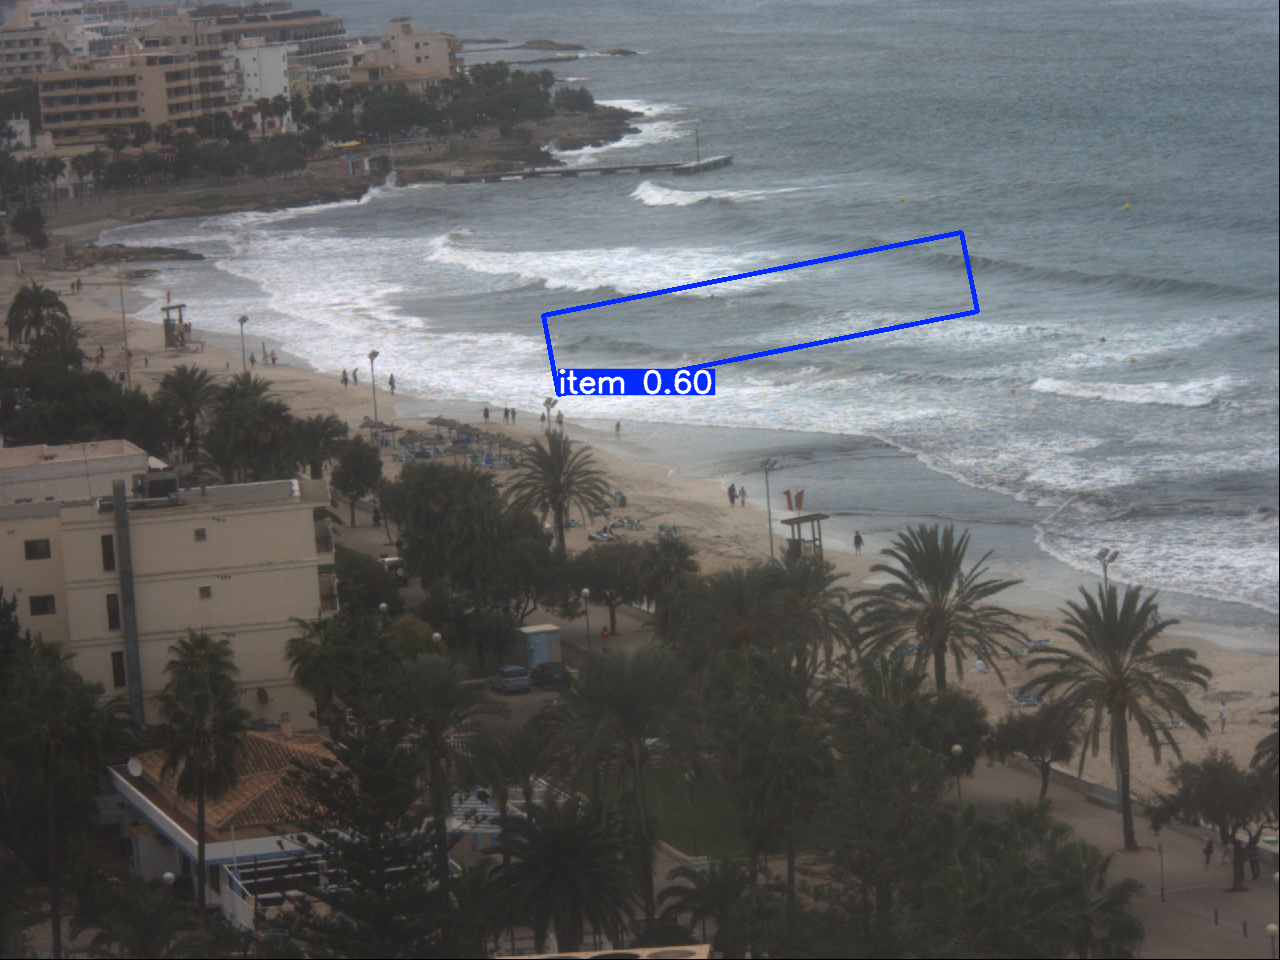

In [11]:
# --- 4. Read and Encode the Image ---
img = cv2.imread(MEDIA_PATH)

if img is None:
    print(f"❌ Error: Could not load image at '{MEDIA_PATH}'. Please check the path.")
else:
    # Encode the image to JPEG format in memory
    success, encoded_img = cv2.imencode('.jpg', img)
    
    if not success:
        print("❌ Error: Failed to encode the image.")
    else:
        # Convert the encoded image to raw bytes
        image_bytes = encoded_img.tobytes()
        
        # Prepare the files dictionary. Standard AI4OS YOLO expects the field to be named "files" or "data".
        files_payload = {
            "files": ("input_image.jpg", image_bytes, "image/jpeg")
        }
        
        print("📤 Sending request to the Rip Currents API...")
        response = requests.post(API_URL, headers=headers, data=payload, files=files_payload)
        
        # --- 5. Handle the Response ---
        if response.status_code == 200:
            print("✅ Request successful!\n")
            
            content_type = response.headers.get('Content-Type', '')
            
            # Check if the response is an image
            if "image" in content_type:
                display(Image(data=response.content))
                
            elif "json" in content_type:
                print(json.dumps(response.json(), indent=4)[:500] + "\n... [Truncated]")
                
        else:
            print(f"❌ Request failed with status code: {response.status_code}")
            print("Response text:", response.text)